# Sweep a parameter and tabulate

This notebook layers the *override + multi-run* pattern on top of the load → run → DataFrame loop from [notebook 1](01_load_run_plot.ipynb):

1. Load a small mission script once per run.
2. Override `Sat.SMA` from Python before each run.
3. Collect a scalar of interest (terminal altitude) into a tidy DataFrame.
4. Plot the trend with matplotlib.

We drive a minimal LEO mission script that ships next to this notebook (`leo_keplerian.script` — Keplerian initial state, point-mass Earth, 1 hour of propagation, single `ReportFile` writing position). Sweeping **`Sat.SMA`** scales the orbit; the plot below should walk linearly with the input grid.

**Prerequisites.** A local GMAT install (R2026a is the primary development target) and `pip install gmat-run[examples]` for the matplotlib dependency.

## Set up the run

Resolve the GMAT install once and confirm the script is where we expect it. The script lives next to this notebook so the path is machine-independent.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gmat_run import Mission, locate_gmat

install = locate_gmat()
script_path = Path("leo_keplerian.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       leo_keplerian.script
Exists:       True


## Define the sweep grid

Eight semi-major-axis values from 7000 km (~622 km altitude) up to 8400 km (~2022 km altitude). The exact grid is incidental — the point is that *every* one of these runs reuses the same script with a single field overridden from Python.

In [2]:
sma_values = np.linspace(7000.0, 8400.0, 8)
sma_values

array([7000., 7200., 7400., 7600., 7800., 8000., 8200., 8400.])

## Run the sweep

One `Mission.load` per run keeps each iteration independent — the spacecraft state is freshly parsed from the script before the override, so a write in one run can't leak into the next. The override goes through dotted-path subscript access, the same way the [Getting started guide](https://astro-tools.github.io/gmat-run/getting-started/) writes individual fields.

After each run we lazy-parse the `ReportFile` to a DataFrame, derive altitude from $\sqrt{X^2 + Y^2 + Z^2} - R_\oplus$, and grab the last row's altitude as the per-run scalar of interest.

In [3]:
EARTH_RADIUS_KM = 6378.137  # WGS-84 equatorial radius

summary_rows = []
per_run_frames = []
for sma in sma_values:
    mission = Mission.load(script_path)
    mission["Sat.SMA"] = float(sma)
    result = mission.run()

    df = result.reports["RF"].copy()
    position = df[["Sat.X", "Sat.Y", "Sat.Z"]]
    df["Altitude_km"] = (position**2).sum(axis=1) ** 0.5 - EARTH_RADIUS_KM
    df["SMA_km"] = float(sma)
    per_run_frames.append(df)

    summary_rows.append(
        {
            "SMA_km": float(sma),
            "TerminalAltitude_km": float(df["Altitude_km"].iloc[-1]),
        }
    )

summary = pd.DataFrame(summary_rows)
combined = pd.concat(per_run_frames, ignore_index=True)
summary

,SMA_km,TerminalAltitude_km
0,7000.0,627.039064
1,7200.0,827.892956
2,7400.0,1028.594123
3,7600.0,1229.148749
4,7800.0,1429.566322
5,8000.0,1629.858161
6,8200.0,1830.036378
7,8400.0,2030.113166


`combined` is the long-form DataFrame with one row per (run × timestep) — useful for overlay plots and group-by analyses. The `SMA_km` column is the run-id.

In [4]:
combined.head()

,Sat.UTCGregorian,Sat.X,Sat.Y,Sat.Z,Altitude_km,SMA_km
0,2026-01-01 12:00:00.000,-5936.162915,1590.590059,3336.771210,614.863000,7000.0
1,2026-01-01 12:01:00.000,-6040.931768,1149.786937,3329.772890,614.877667,7000.0
2,2026-01-01 12:04:39.743,-6206.113475,-491.581464,3185.746222,615.179509,7000.0
3,2026-01-01 12:08:32.899,-6001.419050,-2201.001458,2838.173086,615.907931,7000.0
4,2026-01-01 12:12:26.328,-5417.739050,-3773.474882,2311.083824,617.012573,7000.0


## Plot the trend

Two views of the same sweep:

- **Left:** terminal altitude vs commanded SMA — the headline scalar.
- **Right:** altitude trace per run, overlaid — context for the   variation along each orbit. The wave shape is the eccentricity   showing through (`Sat.ECC = 0.001` in the script); the vertical   separation is the SMA sweep.

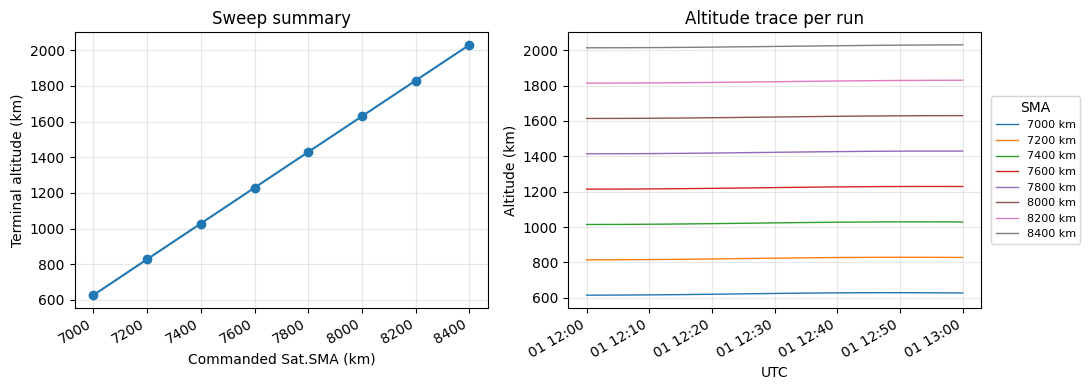

In [5]:
fig, (ax_summary, ax_traces) = plt.subplots(1, 2, figsize=(11, 4))

ax_summary.plot(
    summary["SMA_km"],
    summary["TerminalAltitude_km"],
    marker="o",
    linewidth=1.5,
)
ax_summary.set_xlabel("Commanded Sat.SMA (km)")
ax_summary.set_ylabel("Terminal altitude (km)")
ax_summary.set_title("Sweep summary")
ax_summary.grid(True, alpha=0.3)

for sma, run in combined.groupby("SMA_km"):
    ax_traces.plot(
        run["Sat.UTCGregorian"],
        run["Altitude_km"],
        label=f"{sma:.0f} km",
        linewidth=1,
    )
ax_traces.set_xlabel("UTC")
ax_traces.set_ylabel("Altitude (km)")
ax_traces.set_title("Altitude trace per run")
ax_traces.grid(True, alpha=0.3)
ax_traces.legend(title="SMA", fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Single-machine demo

This loop runs the eight cases sequentially in the current Python process — fine for demos, prototyping, and small grids, but it scales linearly in wall-clock with the run count. Distributed sweeps (thousands of cases, Monte Carlo, parallel workers) are out of scope for `gmat-run` by design — that's the job of the future [`astro-tools/gmat-sweep`](https://github.com/astro-tools) library, which will reuse the same `Mission.load` + override pattern under the hood. The library boundary stays at *one process, one script*; everything above lives in tools that wrap it.

## Where to next

- **Sweep something else.** Any field that the script writes to is   fair game — `Sat.ECC`, `Sat.INC`, `FM.PrimaryBodies`,   `Prop.Accuracy`, propagation duration via   `mission["Prop.InitialStepSize"]`, etc.
- **Persist the artefacts.**   `result.persist("./run_outputs")` after each run copies the   per-case ReportFile / EphemerisFile / log into a permanent location   before the temp workspace is reaped.
- **Combine with other outputs.** `result.ephemerides` and   `result.contacts` work the same way — load once, override, run,   consume each output as a DataFrame.